# Global Happiness & Well Being Analysis


## Data Cleaning, Inspection and Imputation

### Data Inspection (Raw Annual Files)

Reviewing shape metrics and column headers for **2017**, **2018**, and **2019** raw CSVs to identify potential schema drifts prior to concatenation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import country_converter as coco

df1=pd.read_csv("../data/raw/2017.csv")
df2=pd.read_csv("../data/raw/2018.csv")
df3=pd.read_csv("../data/raw/2019.csv")

files=[df1,df2,df3]
for file in files:
    rc=file.shape
    print("=" * 20,"Number Of Rows and Columns","="*20)
    print(f"The file contains {rc[0]} rows and {rc[1]} columns")
    print("\n","=" * 20,"Names Of Columns","="*20)
    print(file.columns)

==================== Number Of Rows and Columns ====================
The file contains 155 rows and 12 columns

 ==================== Names Of Columns ====================
Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='str')
==================== Number Of Rows and Columns ====================
The file contains 156 rows and 9 columns

 ==================== Names Of Columns ====================
Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')
==================== Number Of Rows and Columns ====================
The file contains 156 rows and 9 columns

 ==================== Names Of Columns ===

### Column Renaming & Feature Alignment

Renaming columns across `df1` (2017), `df2` (2018), and `df3` (2019) to ensure seamless row wise concatenation (`pd.concat`) without introducing duplicate or `NaN` columns.

In [2]:
df1=df1.rename(columns={'Happiness.Rank':'Overall rank','Happiness.Score':'Score','Economy..GDP.per.Capita.':'GDP per capita','Health..Life.Expectancy.':'Healthy life expectancy','Trust..Government.Corruption.':'Perceptions of corruption','Family':'Social support'})
df2=df2.rename(columns={'Freedom to make life choices':'Freedom','Country or region':'Country'})
df3=df3.rename(columns={'Freedom to make life choices':'Freedom','Country or region':'Country'})

### Pruning Unnecessary 2017 Features

Dropping confidence interval bounds (`Whisker.*`) and calculation residuals (`Dystopia.Residual`) from `df1` to ensure all annual DataFrames share an identical set of core indicators.

In [3]:
df1=df1.drop(columns=['Whisker.high','Whisker.low','Dystopia.Residual'])

### Injecting Year Columns

Adding `Year` tags (2017, 2018, 2019) to each respective dataset so we can slice, group, and analyze happiness metrics over time once the files are concatenated.

In [4]:
df1['Year']=2017
df2['Year']=2018
df3['Year']=2019

### Final Concatenation & Schema Inspection

Combining all standardized annual datasets into `df` with a clean, reindexed layout. Previewing the top rows to confirm seamless alignment across all features.

In [5]:
df=pd.concat([df1,df2,df3],ignore_index=True)
print(df.shape)
df.head()

(467, 10)


,Country,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom,Generosity,Perceptions of corruption,Year
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2017
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2017
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2017
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2017
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2017


### Data Quality & Missingness Inspection

Checking for missing values (`NaN`) and schema types across `df`. Filtering the dataset specifically for missing `Perceptions of corruption` records to inform imputation strategy.

In [6]:
print("="*20,"Number Of Null Values","="*20)
print(df.isnull().sum())

print("\n","="*20,"Columns Description","="*20)
print(df.info())

df[df['Perceptions of corruption'].isnull()]

==================== Number Of Null Values ====================
Country                      0
Overall rank                 0
Score                        0
GDP per capita               0
Social support               0
Healthy life expectancy      0
Freedom                      0
Generosity                   0
Perceptions of corruption    1
Year                         0
dtype: int64

 ==================== Columns Description ====================
<class 'pandas.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    467 non-null    str    
 1   Overall rank               467 non-null    int64  
 2   Score                      467 non-null    float64
 3   GDP per capita             467 non-null    float64
 4   Social support             467 non-null    float64
 5   Healthy life expectancy    467 non-null    float64
 6   Fr

,Country,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom,Generosity,Perceptions of corruption,Year
174,United Arab Emirates,20,6.774,2.096,0.776,0.67,0.284,0.186,NaN,2018


### Validating Unique Country Year Pairs

Calculating the sum of duplicate `(Year, Country)` combinations in `df` to confirm that each country entry is unique per annual survey.

In [7]:
duplicated_countries=df.duplicated(subset=['Year','Country']).sum()
print(f"The duplicate countries in year 2017, 2018, and 2019 are {duplicated_countries}")

The duplicate countries in year 2017, 2018, and 2019 are 0


### Missing Value Imputation For UAE (Year 2018)

Calculating the mean `Perceptions of corruption` value for the United Arab Emirates across 2017 and 2019, then filling the missing 2018 value to restore dataset completeness.

In [8]:
year_17_19=df.loc[(df['Country']=='United Arab Emirates') & ((df['Year']==2017) | (df['Year']==2019)),'Perceptions of corruption'].mean()
df.loc[(df['Country']=='United Arab Emirates') & (df['Year']==2018),'Perceptions of corruption']=year_17_19


### Validating UAE Data Completeness

Filtering for `Country == 'United Arab Emirates'` across all survey years to confirm that the 2018 `Perceptions of corruption` score has been cleanly populated.

In [9]:
df[df['Country']=='United Arab Emirates']

,Country,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom,Generosity,Perceptions of corruption,Year
20,United Arab Emirates,21,6.648,1.626343,1.26641,0.726798,0.608345,0.360942,0.324490,2017
174,United Arab Emirates,20,6.774,2.096000,0.77600,0.670000,0.284000,0.186000,0.253245,2018
331,United Arab Emirates,21,6.825,1.503000,1.31000,0.825000,0.598000,0.262000,0.182000,2019


### Top 10 Highest Average Happiness Scores

Grouping `df` by `Country` and calculating the 3 year mean `Score` to reveal the consistently highest ranking nations between 2017 and 2019.

In [69]:
grouped_score=df.groupby('Country')['Score'].mean()
top_10=pd.DataFrame(grouped_score.sort_values(ascending=False).head(10))
top_10['Group']='Top 10'
top_10

,Score,Group
Country,,
Finland,7.623333,Top 10
Norway,7.561667,Top 10
Denmark,7.559000,Top 10
Iceland,7.497667,Top 10
Switzerland,7.487000,Top 10
Netherlands,7.435333,Top 10
New Zealand,7.315000,Top 10
Sweden,7.313667,Top 10
Canada,7.307333,Top 10


### Top 10 Lowest Average Happiness Scores

Sorting the 3 year mean `Score` in ascending order to extract the 10 lowest ranking countries between 2017 and 2019.

In [66]:
bottom_10=pd.DataFrame(grouped_score.sort_values(ascending=True).head(10))
bottom_10['Group']='Bottom 10'
bottom_10

,Score,Group
Country,,
Central African Republic,2.953000,Bottom 10
Burundi,3.195000,Bottom 10
South Sudan,3.232667,Bottom 10
Tanzania,3.294333,Bottom 10
Rwanda,3.404333,Bottom 10
Yemen,3.442667,Bottom 10
Syria,3.462000,Bottom 10
Afghanistan,3.543000,Bottom 10
Haiti,3.594000,Bottom 10


### Correlation Calculation For Selected Columns

Calculated correlation among different columns to check the strength and direction of the linear relationship.

In [55]:
selected_col=['Score', 'GDP per capita', 'Social support','Healthy life expectancy', 'Freedom', 'Generosity','Perceptions of corruption']
correlation=df[selected_col].corr(numeric_only=True)
correlation

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom,Generosity,Perceptions of corruption
Score,1.000000,0.797052,0.758071,0.750628,0.549655,0.116574,0.407754
GDP per capita,0.797052,1.000000,0.696427,0.781642,0.344916,-0.005791,0.332820
Social support,0.758071,0.696427,1.000000,0.643913,0.422594,0.002014,0.202775
Healthy life expectancy,0.750628,0.781642,0.643913,1.000000,0.318608,-0.030055,0.270219
Freedom,0.549655,0.344916,0.422594,0.318608,1.000000,0.264407,0.453481
Generosity,0.116574,-0.005791,0.002014,-0.030055,0.264407,1.000000,0.322505
Perceptions of corruption,0.407754,0.332820,0.202775,0.270219,0.453481,0.322505,1.000000


The correlation table shows that Score has the strongest association with `GDP per capita`, `Social support`, and `Healthy life expectancy` suggesting that countries with stronger economies also tend to have better social support systems and health outcomes, and these factors move together closely with happiness. `Freedom` and `Perceptions of corruption` show a moderate **positive association** with `Score`, while `Generosity` stands out with a notably **weak correlation (0.12)** likely because it measures giving relative to income rather than income itself, making it less directly tied to overall happiness. It's worth noting that correlation does not imply causation a strong economy does not automatically guarantee **freedom, low corruption, or generosity** these are separate dimensions that a country's wealth alone doesn't determine.

### Generating Continents For Countries

Using country_converter to map each unique value in Country to its corresponding continent since the raw dataset doesn't include a region/continent column needed for the regional comparison analysis. Results are stored in `country_region_df` for merging with the main `df` so that further analysis can be done.

In [13]:
unique_countries=df['Country'].unique()
cont=coco.convert(names=unique_countries, to='continent')
country_region_df = pd.DataFrame({
    'Country': unique_countries,
    'Continent': cont
})
country_region_df.shape

(164, 2)

### Merging country_region_df & df

Performing a **left join** of `country_region_df` onto `df` using Country as the key, preserving all original rows while attaching the corresponding `Continent` for each entry. Verifying row and column counts post merge to confirm no rows were lost or duplicated

In [14]:
merging=df.merge(country_region_df, on='Country',how='left')
merging.shape

(467, 11)

### Post Merge Verification

Checking for null values in the `Continent` column to confirm every country was successfully mapped and none were left unmatched after the merge. Once verified, `merging` is assigned back to `df` as the main working dataframe, and the top 5 rows are previewed to confirm everything looks correct.

In [15]:
merging['Continent'].isnull().sum()

np.int64(0)

In [16]:
df=merging

In [17]:
df.head()

,Country,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom,Generosity,Perceptions of corruption,Year,Continent
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2017,Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2017,Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2017,Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2017,Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2017,Europe


### Calculating Mean And Standard Deviation Per Continent

Grouped df by `Continent` and calculated the **mean** and **standard deviation** of `Score` for each group. **Mean** shows the average happiness level per continent, while **standard deviation** shows how consistent or spread out that happiness is among countries within the same continent helping identify continents with more internal variation.

In [18]:
grouped_continent=df.groupby('Continent')['Score'].agg(['mean','std']).reset_index()
grouped_continent

,Continent,mean,std
0,Africa,4.299571,0.655906
1,America,6.052268,0.763256
2,Asia,5.281277,0.853764
3,Europe,6.193375,0.902771
4,Oceania,7.288167,0.035227


Above **mean** and **standard deviation** table shows that `Oceania` has the **highest average happiness** score `(7.29)` with an unusually **low standard deviation** `(0.035)` suggesting the countries within this group score very similarly though this should be interpreted cautiously since `Oceania` has far fewer country-year records than other continents. `Africa` has the **lowest average** score `(4.30)`, reflecting the concentration of countries facing conflict, poverty, or instability in this group. `Asia` shows the **highest standard deviation** `(0.85)` among the larger continents, which makes sense given it spans a wide range of circumstances from wealthy, `high scoring East Asian` nations to `lower scoring South Asian` and `Middle Eastern countries`. This shows that averages alone can be misleading; a continent's mean score can mask significant internal disparity, especially in more diverse regions like `Asia`.

### Country Count Per Continent

Counting the number of country-year records per continent to check group sizes behind the **mean** and **standard deviation** values above important context for interpreting `Oceania's` **low standard deviation**, since a small sample size can make a group appear more consistent than it truly is.

In [19]:
df.groupby('Continent')['Country'].size()

Continent
Africa     133
America     71
Asia       137
Europe     120
Oceania      6
Name: Country, dtype: int64

### Data Export

The cleaned dataset with audited date types, combined columns from all three separate csv files from year 2017 to 2019, and verified missingness is exported to the processed data directory for further visualization and reporting.

In [79]:
df.to_csv("../data/processed/cleaned_&_combined_3_years_data.csv",index=False)

## Visualization

### Plot Styling Helper `styled`
To maintain the styling consistency on our charts we have created a reusable function named `styled`. It applies clean **figure style** with **left aligned headings**, **background gridlines**, **readable and not too harsh labels** and **minimal font stylings**.

In [20]:
def styled(ax,title="", xlabel="", ylabel=""):
    ax.set_title(title, fontsize=14, fontweight='bold', color='#222222', pad=12, loc='left')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='medium', color='#333333', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, fontweight='medium', color='#333333', labelpad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')
    ax.tick_params(axis='both', labelsize=7, color='#333333') 
    ax.grid(True, axis='both', linestyle='--', alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True) 

### Correlation Heatmap

Visualizing the **correlation matrix** between `Score` and `all socioeconomic factors` using a **heatmap**, with color intensity representing the strength and direction of each relationship, scaled from **-1 to +1** for accurate interpretation.

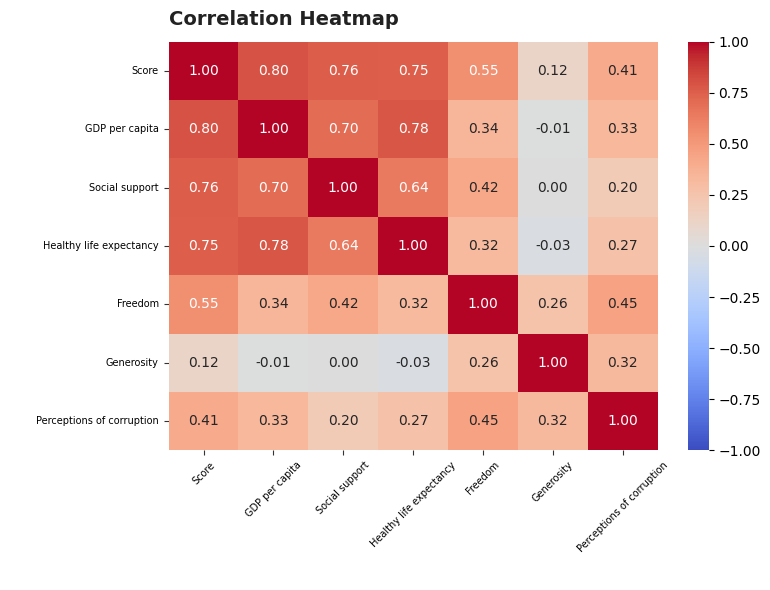

In [74]:
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(data=correlation, annot=True, cmap='coolwarm',fmt='.2f',vmin=-1,vmax=+1)
styled(ax, title="Correlation Heatmap", xlabel=" ", ylabel=" ")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png', dpi=300,bbox_inches='tight')
plt.show()

The heatmap confirms `GDP per capita (0.80)`, `Social support (0.76)`, and `Healthy life expectancy (0.75)` as the factors most strongly associated with happiness Score, shown by the darkest red cells in the Score row/column. `Generosity` stands out with almost no correlation to `Score (0.12)` and near zero correlation with most other factors, appearing pale/neutral across the grid. The heatmap also visually reinforces that `GDP`, `Social support`, and `Life expectancy` are moderately correlated with each other **(0.64–0.78)**, suggesting these top factors overlap rather than acting as fully independent drivers of happiness.

### Regional Comparison Chart

Visualizing **mean** `happiness Score` by `Continent` as a **bar chart**, with **error bars** representing **standard deviation** to show how consistent or spread out happiness is among countries within each continent.

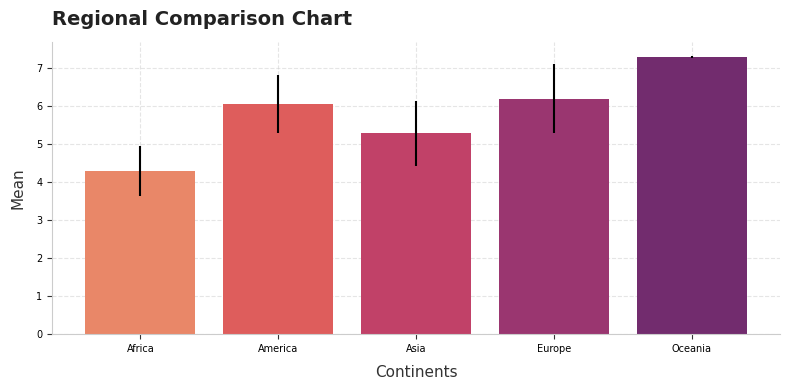

In [ ]:
fig,ax=plt.subplots(figsize=(8,4))
palette = sns.color_palette("flare", n_colors=len(grouped_continent))
ax.bar(x=grouped_continent['Continent'],height=grouped_continent['mean'], yerr=grouped_continent['std'], color=palette )
styled(ax,title="Regional Comparison Chart", xlabel="Continents",ylabel="Mean")
plt.tight_layout()
plt.savefig('../visuals/regional_comparison_chart.png', dpi=300,bbox_inches='tight')
plt.show()

`Oceania` shows the **highest mean** `Score (7.29)` with a barely visible error bar, reflecting very low variation though this should be read cautiously given its small sample size **(6 country-year records)** compared to other continents. `Europe` and `America` follow with similarly **high means** `(~6.05–6.19)` but noticeably wider error bars, indicating greater internal variation in happiness across their countries. `Africa` has the **lowest mean** `Score (4.30)` with moderate spread, while `Asia`, despite a **mid range mean** `(5.28)`, shows one of the widest error bars consistent with its broad diversity of countries ranging from `wealthy East Asian nations to lower scoring South Asian and Middle Eastern countries`.

### Score Distribution

Visualizing the distribution of mean happiness `Score` (2017–2019 average) across all **164 countries** using a histogram, to understand the overall shape and spread of global happiness levels.

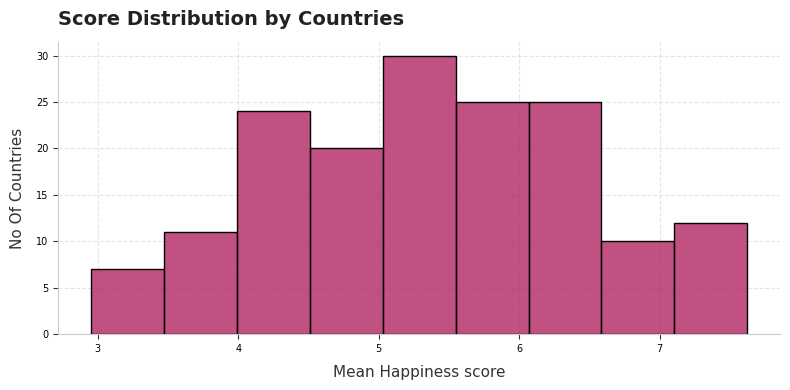

In [76]:
score=pd.DataFrame(df.groupby('Country')['Score'].mean())
fig,ax=plt.subplots(figsize=(8,4))
sns.histplot(x='Score',data=score,color='#AD1759')
styled(ax,title="Score Distribution by Countries",xlabel="Mean Happiness score",ylabel="No Of Countries")
plt.tight_layout()
plt.savefig('../visuals/score_distribution_by_countries.png', dpi=300,bbox_inches='tight')
plt.show()

The distribution shows most countries **clustered in the moderate to high range** with the largest concentration (30 countries) scoring between **5.0 – 5.5** and a broader bulk of **countries (roughly 4.0 – 6.5)** making up the majority of the dataset. Relatively few countries fall at the extremes only **7 countries score below 3.5**, and just **12 score above 7.0** indicating that very low or very high national happiness is uncommon most nations sit somewhere in the moderate middle rather than at either extreme.

### Top 10 & Bottom 10 Countries by Happiness Score

Combining the `top 10` and `bottom 10` countries (by 2017–2019 mean Score) into a single bar chart, with hue used to visually distinguish the happiest nations from the least happy.

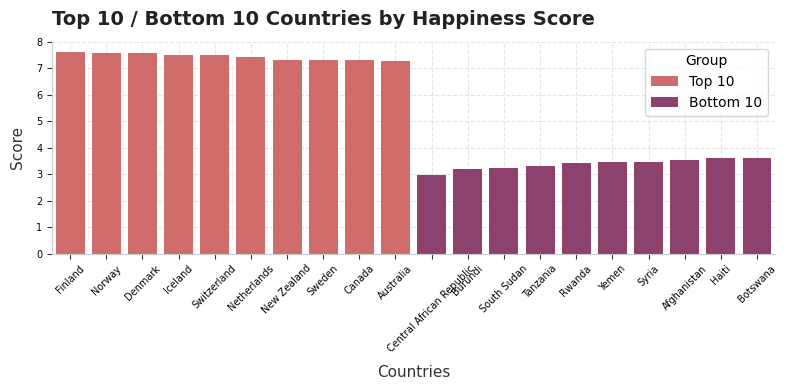

In [81]:
combined=pd.concat([top_10,bottom_10]).reset_index()
fig,ax=plt.subplots(figsize=(8,4))
sns.barplot(x='Country',y='Score',data=combined,hue='Group', palette='flare')
styled(ax,title="Top 10 / Bottom 10 Countries by Happiness Score", xlabel="Countries",ylabel="Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/Top_10_&_Bottom_10_Countries_by_Happiness_Score.png', dpi=300,bbox_inches='tight')
plt.show()

The `top 10` happiest countries are almost entirely **Nordic and Western European/developed nations** **(Finland, Norway, Denmark, Iceland, Switzerland, etc.)**, all clustered tightly between **7.2 – 7.6**. The `bottom 10` are dominated by countries facing **conflict, poverty, or political instability (Central African Republic, South Sudan, Yemen, Syria, Afghanistan)**, scoring between **2.9 – 3.6**. The gap between the two groups is stark even the lowest scoring `top 10` country **(Australia, 7.26)** scores more than double the highest scoring `bottom 10` country **(Botswana, 3.61)** ,underscoring how unevenly happiness is distributed globally.